In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
sns.set(color_codes=True)
import warnings
warnings.filterwarnings("ignore")

In [8]:
df = pd.read_excel(r"C:\Users\Admin\Desktop\UM ASSIGNMENTS\Employee Dataset.csv.xlsx")
df.head()

,id,groups,age,healthy_eating,active_lifestyle,salary
0,0,A,36,5,5,2297
1,1,A,26,3,5,1134
2,2,A,61,8,1,4969
3,3,O,24,3,6,902
4,4,O,39,6,2,3574


In [10]:
df.shape

(50, 6)

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                50 non-null     int64
 1   groups            50 non-null     str  
 2   age               50 non-null     int64
 3   healthy_eating    50 non-null     int64
 4   active_lifestyle  50 non-null     int64
 5   salary            50 non-null     int64
dtypes: int64(5), str(1)
memory usage: 2.5 KB


In [13]:
df.describe()

,id,age,healthy_eating,active_lifestyle,salary
count,50.00000,50.000000,50.000000,50.000000,50.000000
mean,24.50000,31.880000,4.920000,5.900000,2027.500000
std,14.57738,8.390082,1.827678,2.022829,1076.861885
min,0.00000,22.000000,1.000000,1.000000,556.000000
25%,12.25000,26.250000,3.250000,5.000000,1134.000000
50%,24.50000,30.000000,5.000000,6.000000,1950.000000
75%,36.75000,35.750000,6.000000,7.000000,2732.250000
max,49.00000,62.000000,9.000000,10.000000,4969.000000


In [14]:
df.describe(include='all')

,id,groups,age,healthy_eating,active_lifestyle,salary
count,50.00000,50,50.000000,50.000000,50.000000,50.000000
unique,NaN,4,NaN,NaN,NaN,NaN
top,NaN,A,NaN,NaN,NaN,NaN
freq,NaN,20,NaN,NaN,NaN,NaN
mean,24.50000,NaN,31.880000,4.920000,5.900000,2027.500000
std,14.57738,NaN,8.390082,1.827678,2.022829,1076.861885
min,0.00000,NaN,22.000000,1.000000,1.000000,556.000000
25%,12.25000,NaN,26.250000,3.250000,5.000000,1134.000000
50%,24.50000,NaN,30.000000,5.000000,6.000000,1950.000000
75%,36.75000,NaN,35.750000,6.000000,7.000000,2732.250000


In [15]:
df.isnull().sum()

id                  0
groups              0
age                 0
healthy_eating      0
active_lifestyle    0
salary              0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
df['groups'].value_counts()

groups
A     20
O     18
AB     6
B      6
Name: count, dtype: int64

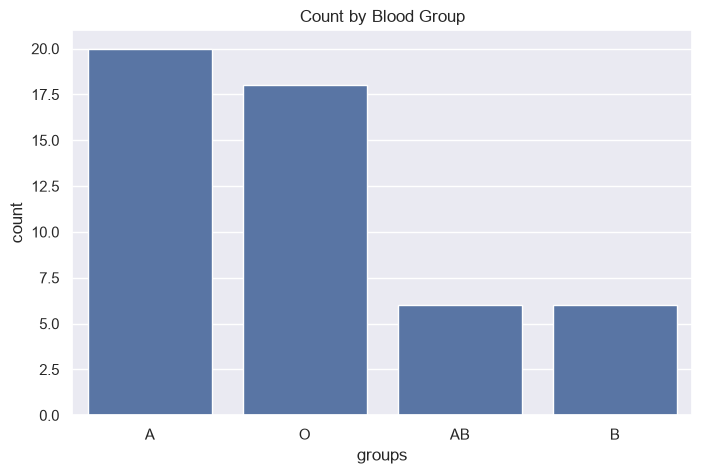

In [18]:
plt.figure(figsize=(8,5))
sns.countplot(x='groups', data = df, order=df['groups'].value_counts().index)
plt.title('Count by Blood Group')
plt.show()

In [19]:
numeric_cols = ['age', 'healthy_eating', 'active_lifestyle', 'salary']

In [20]:
Q1 = df[numeric_cols].quantile(0.25)
Q3 = df[numeric_cols].quantile(0.75)
IQR = Q3 - Q1

outlier_mask = ((df[numeric_cols] < (Q1 - 1.5*IQR)) | (df[numeric_cols] > (Q3 + 1.5*IQR))).any(axis=1)
df_no_outliers = df[~outlier_mask]

print("Original shape:", df.shape)
print("After removing outliers:", df_no_outliers.shape)
print("Outlier rows removed:", outlier_mask.sum())

Original shape: (50, 6)
After removing outliers: (46, 6)
Outlier rows removed: 4


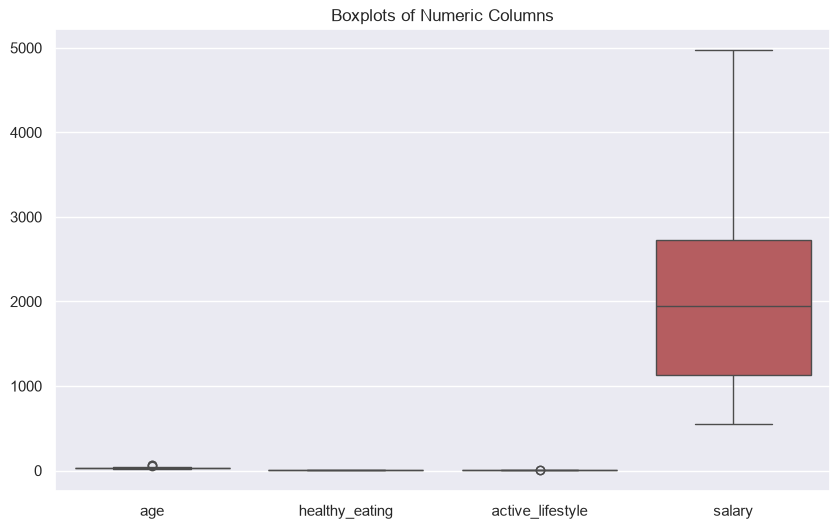

In [21]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df[numeric_cols])
plt.title('Boxplots of Numeric Columns')
plt.show()

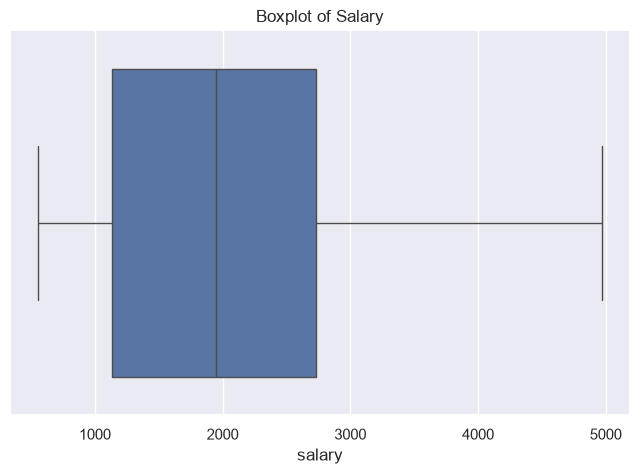

In [22]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['salary'])
plt.title('Boxplot of Salary')
plt.show()

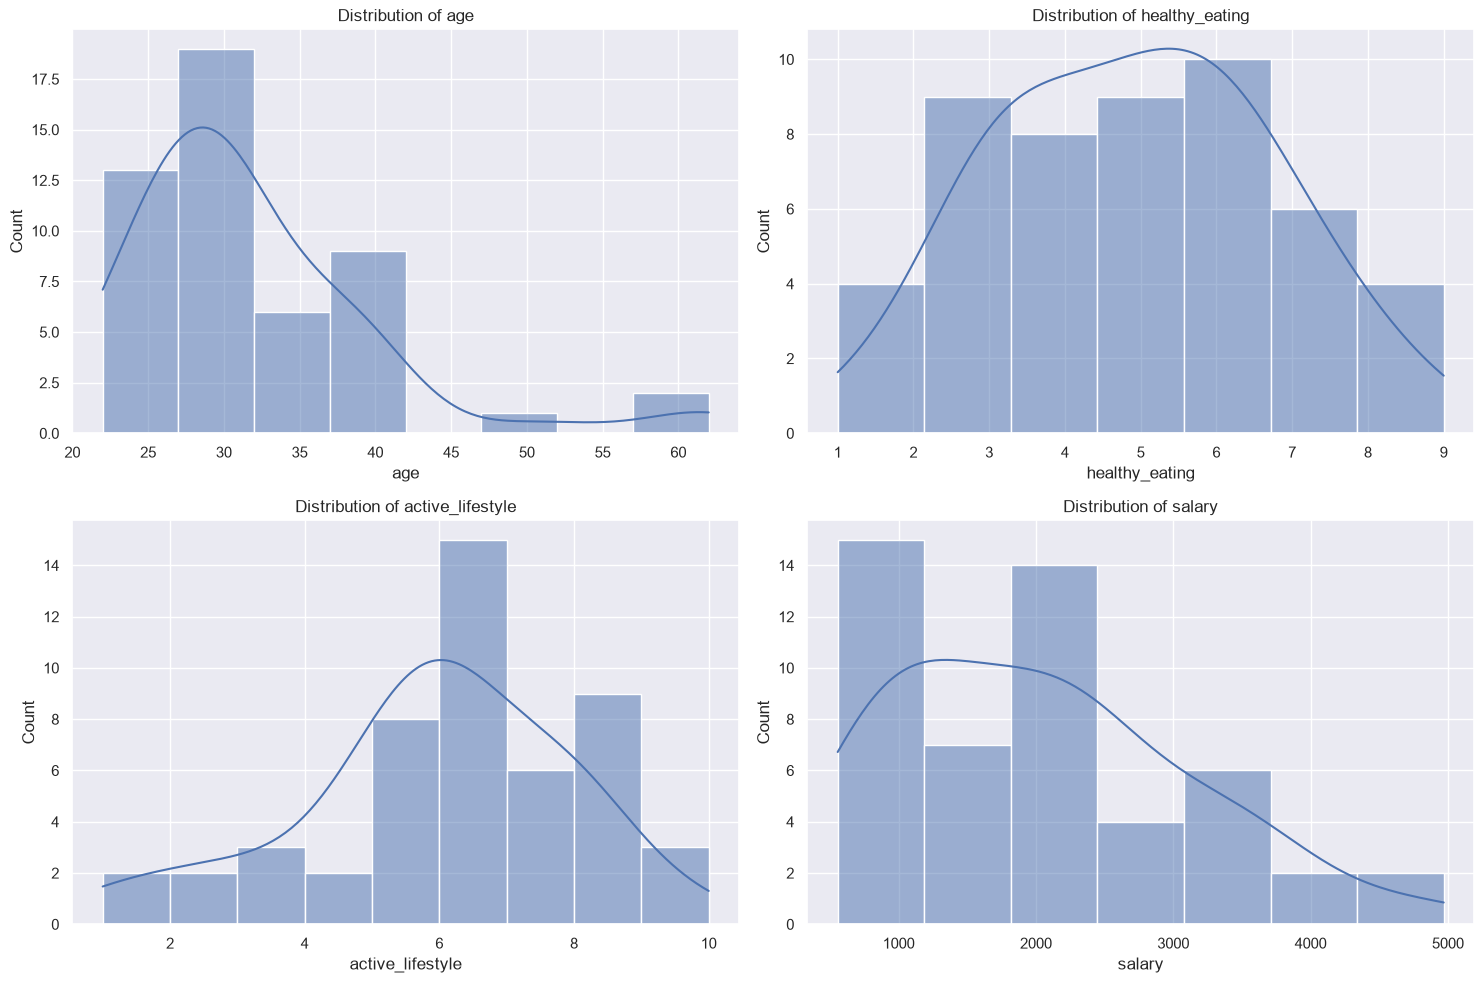

In [23]:
plt.figure(figsize=(15,10))
for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
plt.tight_layout()
plt.show()

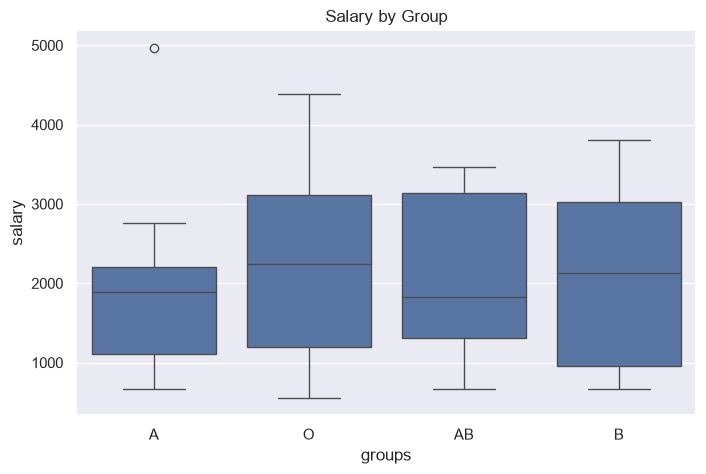

In [24]:
plt.figure(figsize=(8,5))
sns.boxplot(x='groups', y='salary', data=df)
plt.title('Salary by Group')
plt.show()

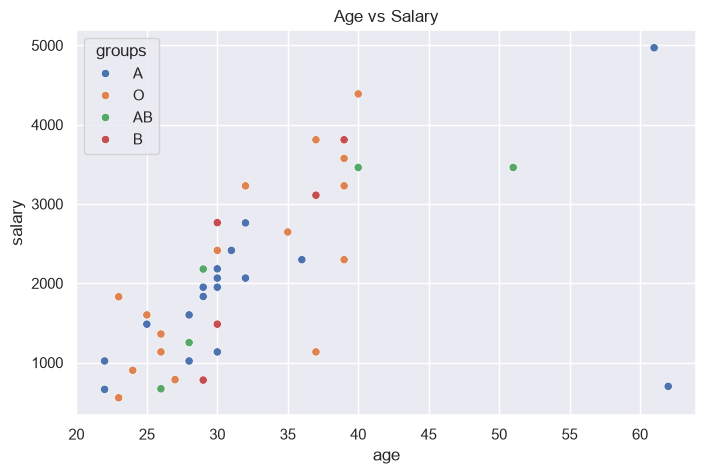

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='age', y='salary', hue='groups', data=df)
plt.title('Age vs Salary')
plt.show()

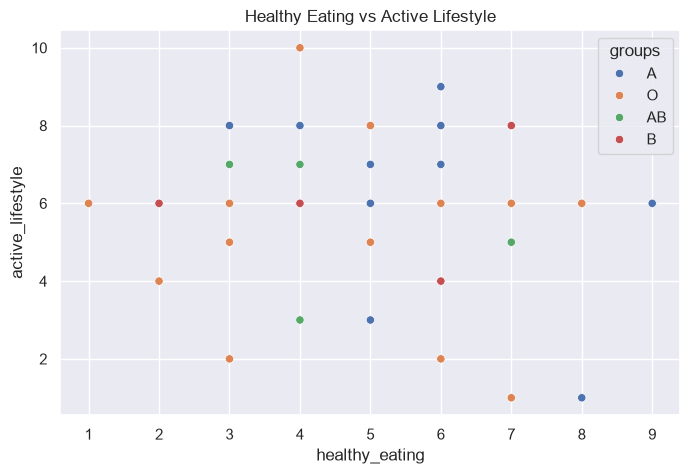

In [26]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='healthy_eating', y='active_lifestyle', hue='groups', data=df)
plt.title('Healthy Eating vs Active Lifestyle')
plt.show()

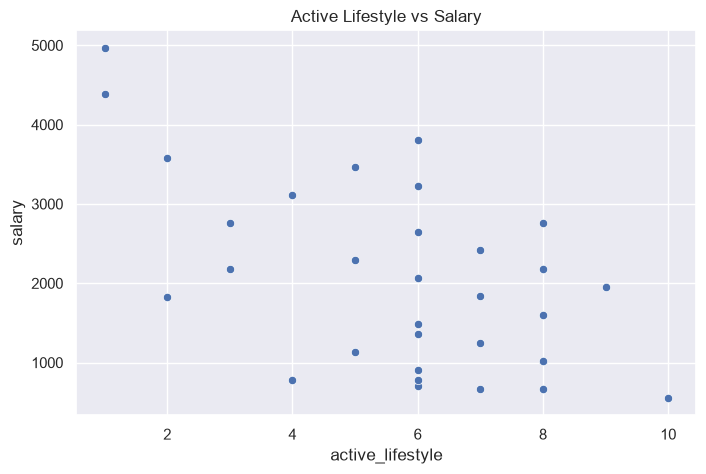

In [27]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='active_lifestyle', y='salary', data=df)
plt.title('Active Lifestyle vs Salary')
plt.show()

In [28]:
corr = df[numeric_cols].corr()
corr

,age,healthy_eating,active_lifestyle,salary
age,1.000000,0.703395,-0.433615,0.594401
healthy_eating,0.703395,1.000000,-0.068449,0.757873
active_lifestyle,-0.433615,-0.068449,1.000000,-0.495540
salary,0.594401,0.757873,-0.495540,1.000000


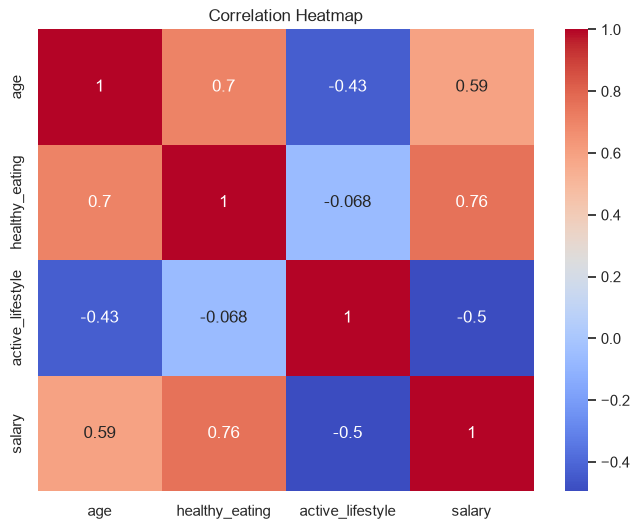

In [29]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

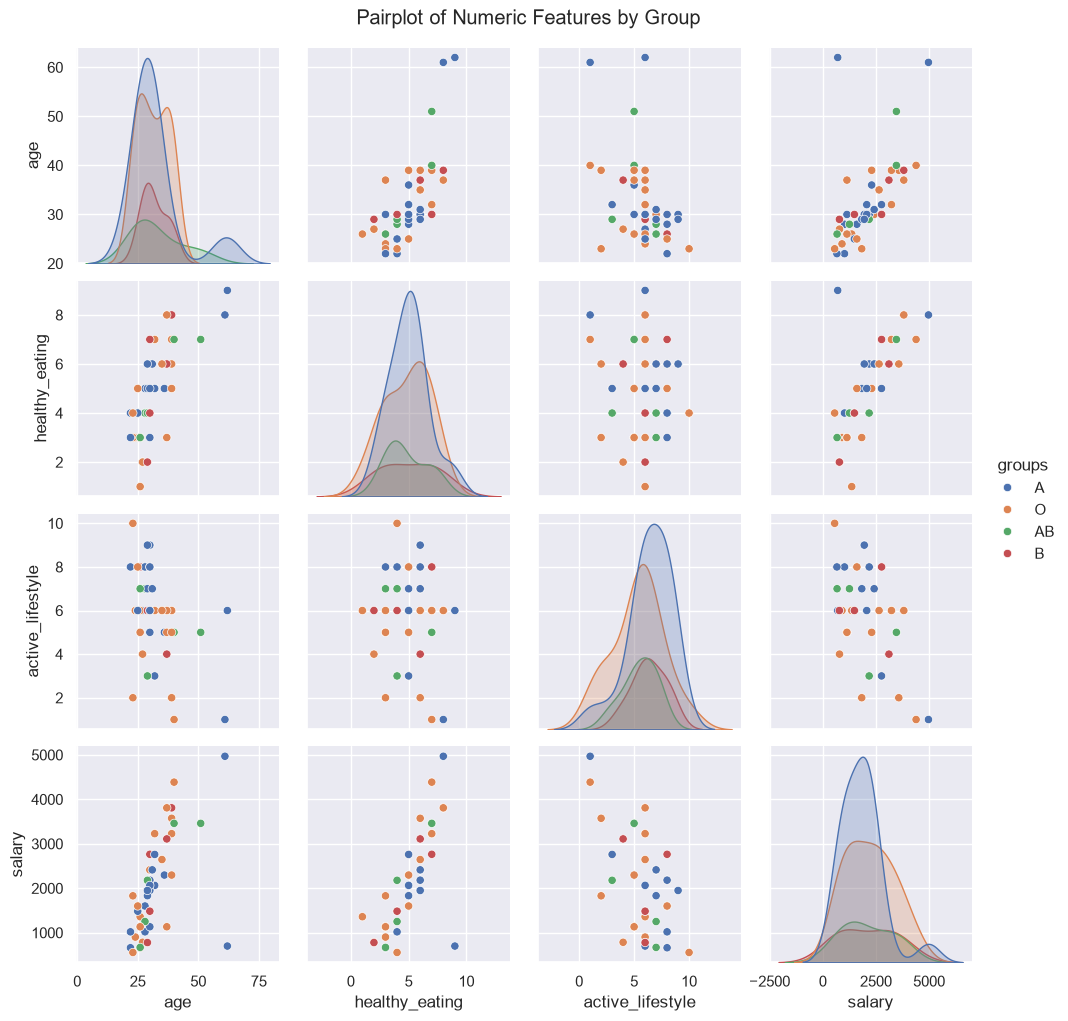

In [30]:
g = sns.pairplot(df[numeric_cols + ['groups']], hue='groups')
g.fig.suptitle('Pairplot of Numeric Features by Group', y=1.02)
plt.show()

In [ ]:
S